In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Remove Customer ID
df.drop("customerID", axis=1, inplace=True)

# Encode target column
df["Churn"] = df["Churn"].map({"No":0,"Yes":1})

# Encode categorical columns
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


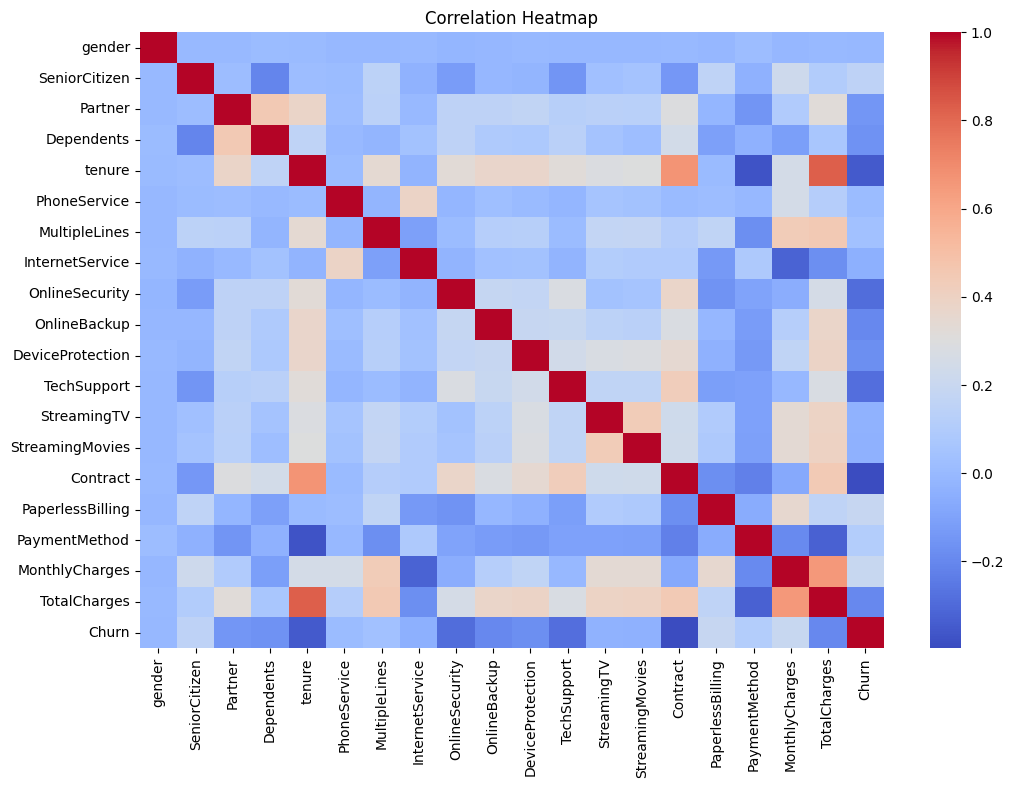

In [4]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [5]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [7]:
print(np.isnan(X).sum())

0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )
}

results = []

In [10]:
for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    probability = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test,prediction)
    precision = precision_score(y_test,prediction)
    recall = recall_score(y_test,prediction)
    f1 = f1_score(y_test,prediction)
    roc = roc_auc_score(y_test,probability)

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :",accuracy)
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1:",f1)
    print("ROC-AUC:",roc)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test,prediction))

    print("\nClassification Report")
    print(classification_report(y_test,prediction))

    results.append([name,accuracy,precision,recall,f1,roc])

Logistic Regression
Accuracy : 0.7991483321504613
Precision: 0.6426332288401254
Recall: 0.5481283422459893
F1: 0.5916305916305916
ROC-AUC: 0.8402387041773232

Confusion Matrix
[[921 114]
 [169 205]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Decision Tree
Accuracy : 0.730305180979418
Precision: 0.49238578680203043
Recall: 0.5187165775401069
F1: 0.5052083333333334
ROC-AUC: 0.6625255108631067

Confusion Matrix
[[835 200]
 [180 194]]

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.52      0.51       374

    accuracy                           0.73      1409
   macro avg     

In [11]:
results = pd.DataFrame(results,
columns=["Model","Accuracy","Precision","Recall","F1 Score","ROC-AUC"])

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.799148   0.642633  0.548128  0.591631  0.840239
1        Decision Tree  0.730305   0.492386  0.518717  0.505208  0.662526
2        Random Forest  0.790632   0.633898  0.500000  0.559043  0.819827


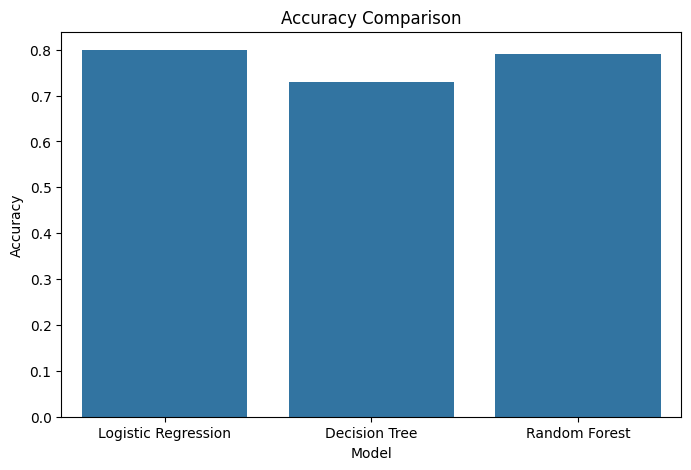

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(data=results,x="Model",y="Accuracy")

plt.title("Accuracy Comparison")

plt.show()

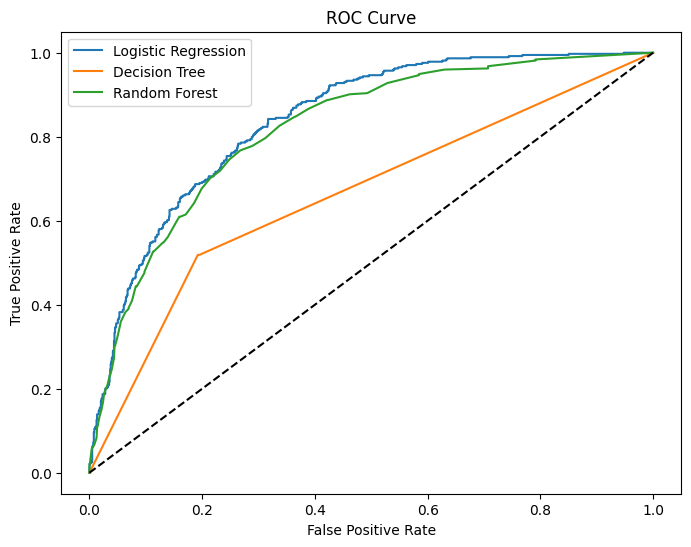

In [13]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    probability = model.predict_proba(X_test)[:,1]

    fpr,tpr,_ = roc_curve(y_test,probability)

    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()